# Droplet fusion
This program analyzes the relaxation time of the droplets during fusion: 
* Programmable Viscoelasticity in Protein-RNA Condensates with Disordered Sticker-Spacer Polypeptides*" by Alshareedah and coworkers.

### Importing necessary libraries and defining the functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from lumicks import pylake
import math
from multipletau import autocorrelate
import array
import lmfit
import scipy as sp
import numpy as np
from scipy.interpolate import interp1d
from obspy.signal.detrend import spline
from os import listdir
from os.path import isfile, join

%matplotlib inline

from pylab import *

def myplot(xlabel,ylabel):
    
    rc('axes', linewidth=1.5)
    fontsize = 14

    ax=gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
        #tick.label1.set_fontweight('bold')
        tick.linewidth=1.5
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
        #tick.label1.set_fontweight('bold')
    plt.xlabel(xlabel,fontsize=18)
    plt.ylabel(ylabel,fontsize=18)
    plt.legend(frameon=False)
    grid()

# Opening the data file
Here, the code is written to handle .h5 files obtained from Lumicks bluelake software that operates the C-trap correlative optical tweezer-confocal microscopy system. the code can be edited to open other files. The needed data is the X-coordinates, Y-coordinates, and time arrays. 

In [76]:
# List the h5 files in the directory
import os

testdir = r"D:\Anurag_data\Droplet fusion\PolyA condensates\500mM KCl\20"
os.listdir(testdir)
os.chdir(testdir)
os.getcwd()

files = listdir()
scans = []
fraps=[]
for file in files:
    if '.h5' in file  :
        scans.append(file)
index = np.arange(len(scans))
insca = zip(list(index),scans)
list(insca)


[(0, '20231023-184629 Marker 19.h5')]

In [77]:
# Pick a file to analyze
index_to_analyze =0
fname=scans[index_to_analyze]
fname=fname[0:len(fname)-3]
file1 = pylake.File(fname+'.h5')
#file2 = pylake.File("data/20180611-161216 Kymograph 6.h5")
#print(file1)

beadfx = file1['Force HF']['Force 1x']
beadfx1 = beadfx.data
beadfy = file1['Force HF']['Force 1y']
beadfy1 = beadfy.data
beadfx = file1['Force HF']['Force 2x']
beadfx2 = beadfx.data
beadfy = file1['Force HF']['Force 2y']
beadfy2 = beadfy.data

In [78]:
file1['Power controls']['Overall power'].data[:10]

array([4.99991449])

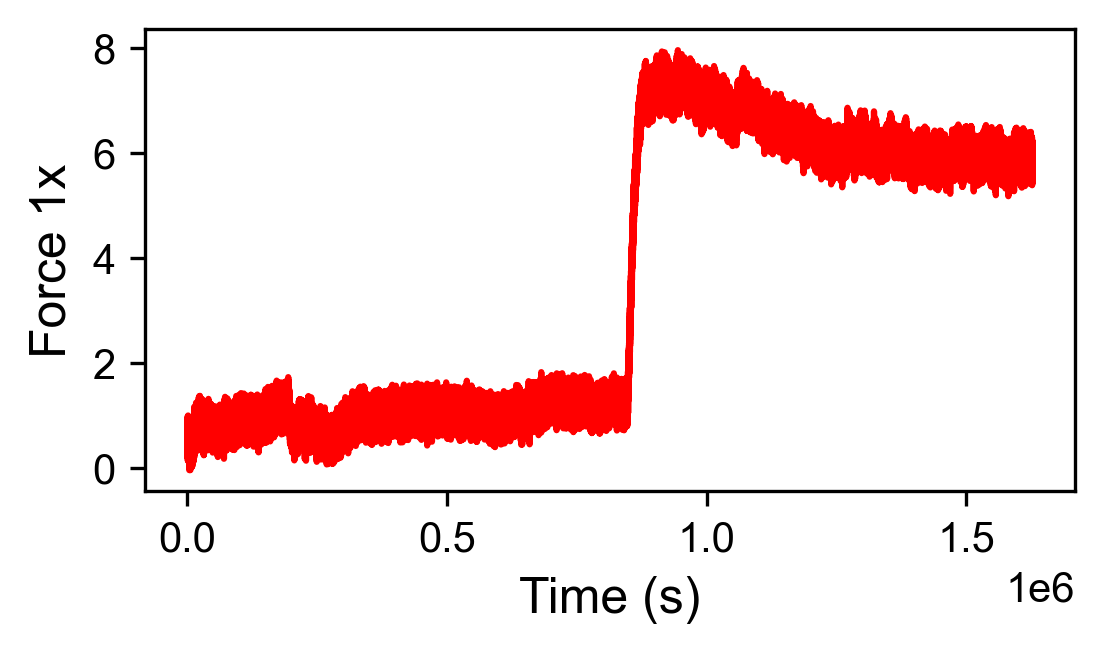

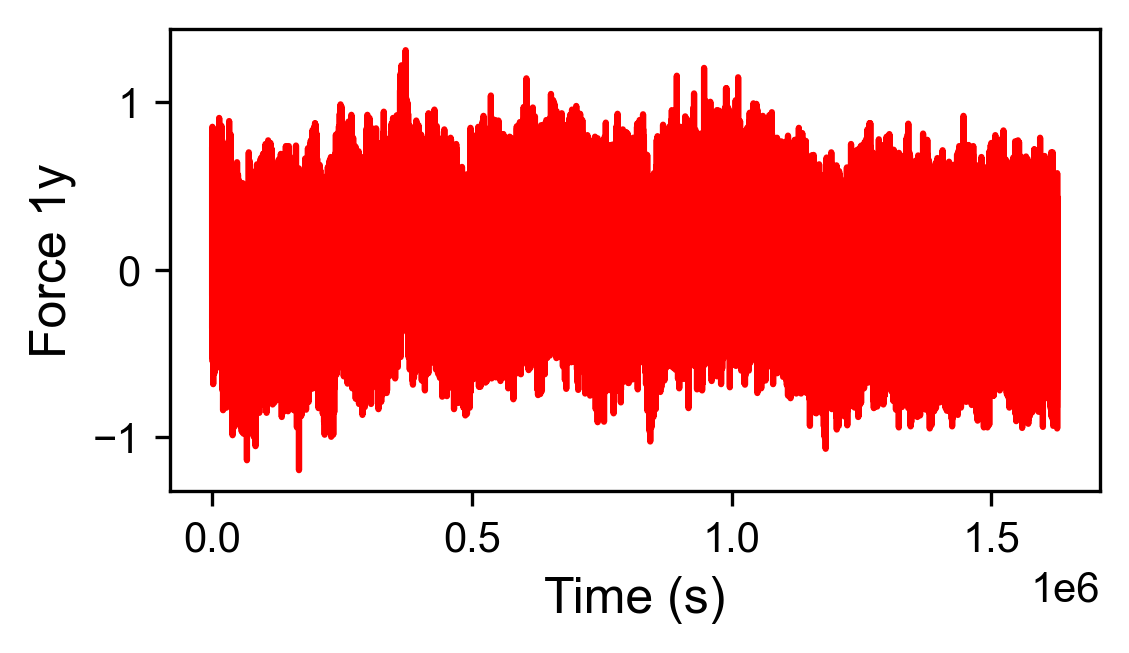

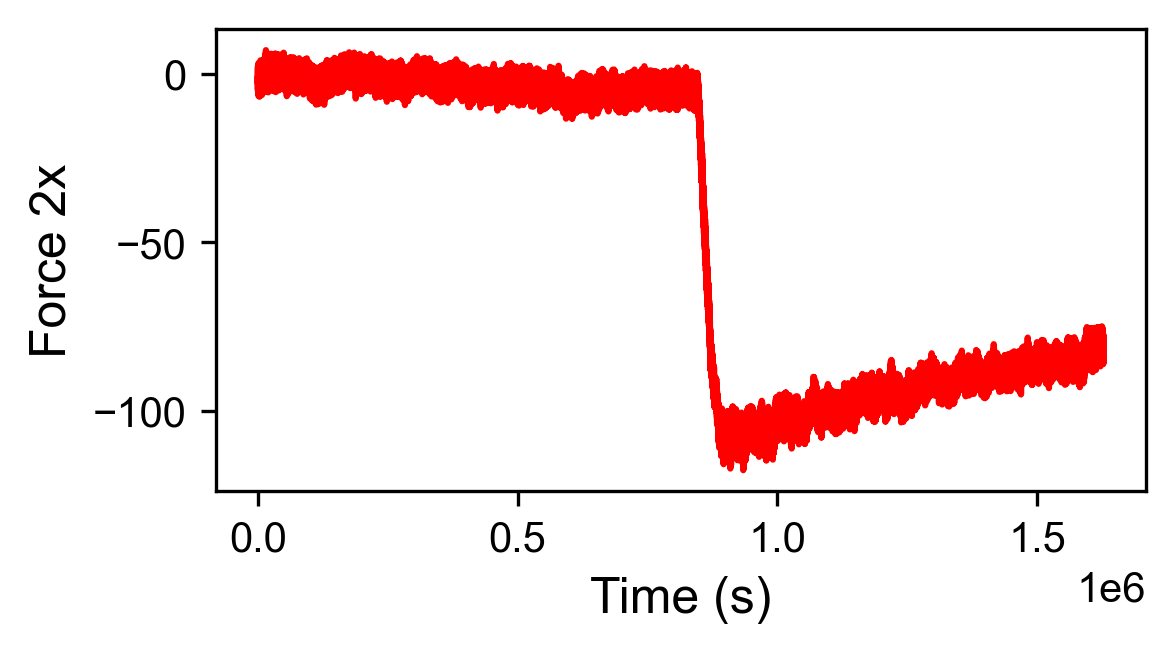

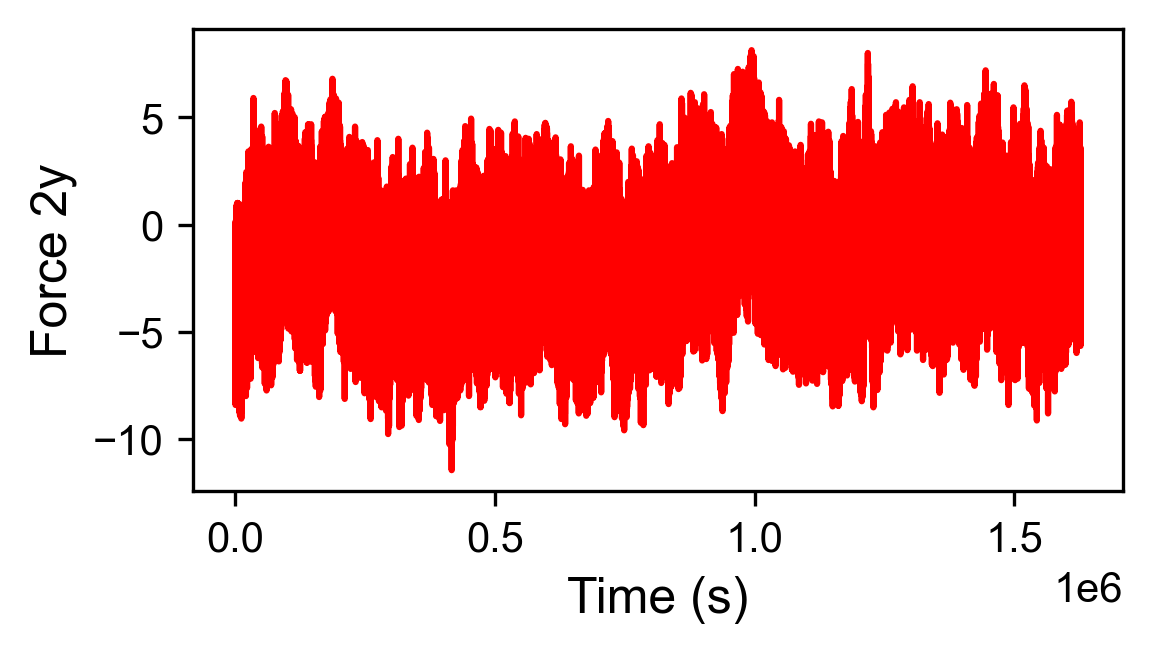

In [79]:
plt.figure(figsize=(4,2),dpi=300)
matplotlib.rcParams['font.sans-serif'] = "Arial"
plt.plot(beadfx1,'red')
plt.xlabel("Time (s)",fontsize=12)
plt.ylabel("Force 1x",fontsize=12)
#plt.ylim([-0.01,0.01])
plt.savefig(fname+'Force 1x.svg')
plt.savefig(fname+'Force 1x.png',bbox_inches='tight')
np.savetxt(fname+"Force_1x.txt", np.transpose(np.array([beadfx1])),delimiter='\t')

plt.figure(figsize=(4,2),dpi=300)
matplotlib.rcParams['font.sans-serif'] = "Arial"
plt.plot(beadfy1,'red')
plt.xlabel("Time (s)",fontsize=12)
plt.ylabel("Force 1y",fontsize=12)
#plt.ylim([-0.01,0.01])
plt.savefig(fname+'Force 1y.svg')
plt.savefig(fname+'Force 1y.png',bbox_inches='tight')
np.savetxt(fname+"Force_1y.txt", np.transpose(np.array([beadfy1])),delimiter='\t')

plt.figure(figsize=(4,2),dpi=300)
matplotlib.rcParams['font.sans-serif'] = "Arial"
plt.plot(beadfx2,'red')
plt.xlabel("Time (s)",fontsize=12)
plt.ylabel("Force 2x",fontsize=12)
#plt.ylim([-0.01,0.01])
plt.savefig(fname+'Force 2x.svg')
plt.savefig(fname+'Force 2x.png',bbox_inches='tight')
np.savetxt(fname+"Force_2x.txt", np.transpose(np.array([beadfx2])),delimiter='\t')

plt.figure(figsize=(4,2),dpi=300)
matplotlib.rcParams['font.sans-serif'] = "Arial"
plt.plot(beadfy2,'red')
plt.xlabel("Time (s)",fontsize=12)
plt.ylabel("Force 2y",fontsize=12)
#plt.ylim([-0.01,0.01])
plt.savefig(fname+'Force 2y.svg')
plt.savefig(fname+'Force 2y.png',bbox_inches='tight')
np.savetxt(fname+"Force_2y.txt", np.transpose(np.array([beadfy2])),delimiter='\t')